# **Лекция №5: Tele-gram**


# Telegram-боты: Часть 1. Фундамент
## Введение для будущих аналитиков
Вы уже знаете, что Python — это мощный калькулятор. Вы знаете про классы, декораторы и исключения. Но пока ваш код жил в вакууме: запустили скрипт -> он посчитал -> умер.

**Сегодня мы сделаем код, который живет вечно (ну, пока не упадет сервер) и общается с людьми.**

### Зачем это аналитику?
1.  **Интерфейс к данным.** Заказчик не будет запускать ваши скрипты в PyCharm/ Юпайтере. Ему нужна кнопка "Сделать красиво" в телефоне.
2.  **Сбор данных.** Бот может собирать отчеты, геопозицию, фото чеков и складывать их в базу.
3.  **Алерты.** Модель упала? Сервер перегрелся? Бот напишет вам лично.

Аналитик данных без знания автоматизации — это просто человек, который очень быстро нажимает `Ctrl+C` -> `Ctrl+V`.
Боты позволяют вам:
1.  **Делегировать рутину.** Сбор отчетов, пересылка файлов, алерты.
2.  **Создавать интерфейсы.** SQL-запрос выглядит страшно. Кнопка "Дай выручку" — дружелюбно.
3.  **Быть ленивым.** Это главная добродетель программиста.
---

## 1.1 Как это работает? (Теория "Официанта")

Интернет работает по принципу **Клиент-Сервер**.
* **Клиент (Вы/Телеграм):** Делает запрос (Request). *"Дай мне котиков"*.
* **Сервер (Бот/Сайт):** Обрабатывает и отдает ответ (Response). *"Вот твой котик"*.

Между ними стоит **API (Application Programming Interface)**.
Представьте, что API — это **Официант** в ресторане.
1.  Вы (Клиент) не идете на кухню (Сервер) жарить мясо. Вы говорите Официанту (API): "Хочу стейк".
2.  Официант бежит на кухню, передает заказ повару.
3.  Повар готовит.
4.  Официант приносит вам еду (или говорит, что мясо кончилось — Ошибка 404).

### Язык общения: JSON
Официант не понимает русский язык. Он понимает **JSON**.
JSON (JavaScript Object Notation) — это формат передачи данных.
Для нас, питонистов, **JSON = Словарь (Dictionary)** + Списки (Lists).

Пример того, что летает по проводам:
```json
{
  "ok": true,
  "result": {
    "message_id": 123,
    "text": "Привет!",
    "from": {"id": 456, "first_name": "Ivan"}
  }
}

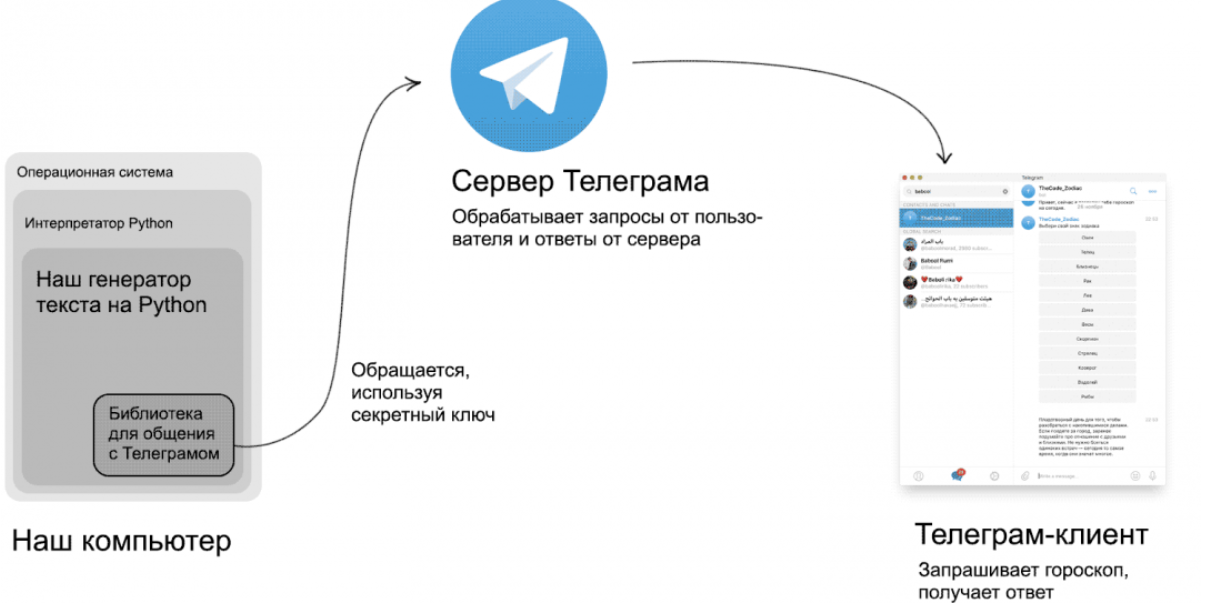

# Типы Telegram-ботов 
## — Чем они живут?

1. **Чат-боты:**
   Они как виртуальные собеседники, которым никто не пишет... кроме вас.  
   Используются для общения в текстовом формате.

2. **Боты-сервис:**
   Эти существуют ради нашего удобства. Пример: бот для заказа пиццы. 🍕  


3. **Викторины и игры:**
   Кто сказал, что бот-игра — это только «угадай слово»? Преферанс в массы!

4. **Интеграционные боты:**
   - Взаимодействуют с внешними API (популярные: прогноз погоды, курсы валют). 

## 1.2 Способы связи: Polling vs Webhook
Как бот узнает, что ему написали?

**Вариант А: Webhook (Стук в дверь)**
Телеграм сам стучится на ваш сервер: "Эй, тут сообщение!".

Плюсы: Быстро, экономно.

Минусы: Нужен "Белый IP", SSL-сертификат, настроенный веб-сервер (Nginx/Apache).

Вердикт: Сложно для старта.

**Вариант Б: Long Polling (Тревожный невротик)**
Ваш скрипт сам долбит сервера Телеграма: "Есть что? А сейчас? А теперь?". Мы открываем соединение и "висим" в ожидании 20-30 секунд.

Плюсы: Работает с любого ноутбука, из-под VPN, не нужен белый IP.

Минусы: Нагружает сеть (незначительно).

Вердикт: Идеально для обучения и MVP.

 Есть три популярные библиотеки для написания Telegram-ботов.

1️⃣ **python-telegram-bot**  
   - Плюсы: популярна, большая документация.  
   - Минусы: мало настроена "на автомат", нужно писать структуры.  

2️⃣ **telebot (PyTelegramBotAPI)**  
   - Плюсы: идеальна для новичков — быстро и просто.  
   - Минусы: тяжело масштабировать сложные проекты.  

3️⃣ **aiogram**  
   - Плюсы: поддержка асинхронности, мощь современного Python.  
   - Минусы: сложнее для освоения новичками.

Мы выберем библиотеку `PyTelegramBotAPI`. Почему? Потому что мне так захотелось).

In [1]:
# Установка необходимых библиотек.
# pyTelegramBotAPI - обертка над API
# python-dotenv - для безопасности (чтение .env файлов)

!pip install pyTelegramBotAPI python-dotenv --quiet
print("Библиотеки установлены. Ready to rock.")


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Библиотеки установлены. Ready to rock.


## 1.3 BotFather: Отец всех ботов

Боты не рождаются из воздуха. Их создает **@BotFather**.

**Базовые команды (знать обязательно):**
* `/newbot` — создать нового бота (получить Токен).
* `/mybots` — управление вашими ботами.
* `/token` — перевыпустить токен (если старый украли).

**UX команды (чтобы бот не выглядел как поделка):**
* `/setuserpic` — аватарка. Без аватарки боту никто не доверяет.
* `/setdescription` — текст, который виден **до** нажатия кнопки "Start". Тут надо продать бота пользователю.
* `/setabouttext` — текст в профиле бота.
* `/setcommands` — меню команд (синяя кнопка "Menu" слева внизу).

## 1.4 Безопасность: Переменные окружения 🔐

**Токен** — это ключи от квартиры, где деньги лежат.
Если вы закоммитите токен в публичный GitHub:
1.  Сканеры найдут его за секунды.
2.  Ваш бот начнет рассылать спам про казино.
3.  Телеграм забанит ваш аккаунт разработчика.

**Как делать правильно:**
Использовать файл `.env`. Это скрытый файл, который не передается в Git (добавляется в `.gitignore`).

Мы сымитируем создание этого файла.

In [26]:
# Эмуляция создания файла .env
# В реальности вы создаете его руками: Файл -> Новый файл -> .env

env_content = """
BOT_TOKEN=5095342266:AAF5r5OgBWJmHm7mSuQW298mbvYrgw4KVlo
ADMIN_ID=73975940
"""

with open(".env", "w") as f:
    f.write(env_content)

print("Файл .env создан. Теперь научим Python его читать.")

Файл .env создан. Теперь научим Python его читать.


In [27]:
import os
from dotenv import load_dotenv # Библиотека для чтения .env
import telebot
import logging # Взрослое логирование вместо print

# 1. Загружаем переменные из файла в окружение
load_dotenv()

# 2. Достаем токен
TOKEN = os.getenv('BOT_TOKEN')

# Проверка на дурака
if not TOKEN or TOKEN == 'ВАШ_ТОКЕН_ЗДЕСЬ_БЕЗ_КАВЫЧЕК':
    print("❌ ОШИБКА: Вы не вставили токен в файл .env (предыдущая ячейка)!")
else:
    print("✅ Токен найден. Продолжаем.")

# 3. Настройка логирования
# print() - это плохо, потому что не видно времени и уровня важности.
# logging - это стандарт.
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')

# 4. Инициализация
bot = telebot.TeleBot(TOKEN)

✅ Токен найден. Продолжаем.


## 1.5 Анатомия сообщения (Вскрытие JSON) 🔪

Когда пользователь пишет боту, `telebot` превращает JSON от Телеграма в объект класса `Message`.
Давайте посмотрим, из чего он состоит. Это критически важно для аналитики: мы должны знать, **кто**, **откуда** и **когда** написал.

Основные поля объекта `message`:
* `message.message_id` — уникальный ID сообщения в этом чате.
* `message.date` — дата отправки (Unix timestamp).
* `message.text` — текст (если это текст).
* `message.from_user` — **Объект User** (отправитель).
    * `.id` — уникальный ID юзера (сохраняется навсегда).
    * `.is_bot` — бот или человек?
    * `.first_name`, `.last_name`, `.username`.
* `message.chat` — **Объект Chat** (где происходит общение).
    * В личке: `chat.id` == `from_user.id`.
    * В группе: `chat.id` — это ID группы (обычно отрицательное число), а `from_user.id` — того, кто написал.

**Важно:** Username юзер может сменить в любой момент. ID — никогда. **В базе данных всегда привязываемся к ID!**

In [29]:
# Пишем "Инспектора" — хендлер, который выворачивает сообщение наизнанку

@bot.message_handler(commands=['inspect'])
def inspector_gadget(message):
    # Достаем данные
    user_id = message.from_user.id
    chat_id = message.chat.id
    username = message.from_user.username
    is_private = (message.chat.type == 'private')
    
    # Формируем отчет аналитика
    report = (
        f"🕵️‍♂️ <b>АНАЛИЗ СООБЩЕНИЯ</b>\n"
        f"--------------------------\n"
        f"🆔 <b>User ID:</b> <code>{user_id}</code>\n"
        f"🆔 <b>Chat ID:</b> <code>{chat_id}</code>\n"
        f"👤 <b>Login:</b> @{username}\n"
        f"🏠 <b>Личка?</b> {is_private}\n"
        f"📄 <b>Текст:</b> {message.text}\n"
        f"💾 <b>Raw JSON:</b>\n<code>{message.json}</code>"
    )
    
    # Отправляем (parse_mode='HTML' позволяет использовать теги)
    bot.reply_to(message, report, parse_mode='HTML')

# Эхо-хендлер для теста
@bot.message_handler(content_types=['text'])
def echo(message):
    logging.info(f"Получено сообщение от {message.from_user.first_name}: {message.text}")
    bot.send_message(message.chat.id, f"Эхо: {message.text}")

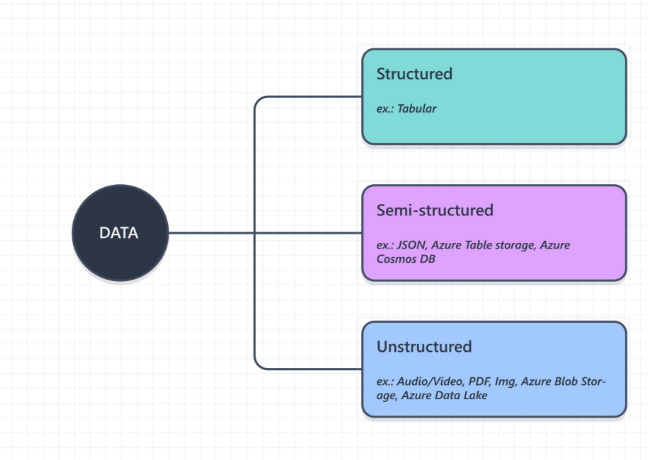

## 1.6 Магия фильтров (Regex и Lambda) 🧙‍♂️

Бот не должен отвечать на всё подряд.
Декоратор `@bot.message_handler` принимает аргументы-фильтры. Если фильтр возвращает `True`, функция выполняется. Если `False` — идем к следующему хендлеру.

**Типы фильтров:**
1.  `commands=['start']` — список команд.
2.  `content_types=['photo']` — тип файла.
3.  `func=lambda m: ...` — произвольная функция (Гибкость!).
4.  `regexp=r'...'` — Регулярные выражения (Мощь!).

**Кейс для аналитика:**
Нам нужно ловить сообщения, где пишут email'ы, чтобы заносить их в базу.

In [30]:
# Пример: Бот реагирует только на слово "Котик" в любом регистре
@bot.message_handler(func=lambda m: m.text and 'котик' in m.text.lower())
def cat_reactor(message):
    bot.reply_to(message, "Мяу! 🐱")

# Пример: Бот ловит email через регулярное выражение
# r'...' - сырая строка
@bot.message_handler(regexp=r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+')
def email_catcher(message):
    bot.reply_to(message, "Я вижу email! Записываю в базу спамеров...")

# Пример: Бот отвечает только АДМИНУ (по ID)
# Замените ID на свой, чтобы проверить
ADMIN_ID = 73975940 
@bot.message_handler(func=lambda m: m.from_user.id == ADMIN_ID)
def admin_secret(message):
    bot.reply_to(message, "Привет, Господин! 👑")

## 1.7 Запуск и Жизненный цикл (Polling Parameters)

Мы используем `infinity_polling`. Что у него внутри?
* `timeout=20`: Бот открывает соединение и ждет 20 секунд. Если тишина — переподключается.
* `long_polling_timeout=20`: Таймаут на стороне Телеграма.

**Почему бот может "умереть"?**
1.  `ReadTimeout`: Интернет моргнул.
2.  `ConnectionError`: Провайдер шалит.
3.  `ApiTelegramException`: Вы пытаетесь отправить сообщение юзеру, который вас заблокировал.

`infinity_polling` пытается обработать сетевые ошибки сам. Ошибки логики (ваш кривой код) он не исправит, но покажет в логах.

In [ ]:
# Финальный запуск Блока 1
if __name__ == '__main__':
    logging.info("Бот запущен и готов служить...")
    
    # skip_pending=True — пропустить сообщения, которые накопились, пока бот спал
    # (чтобы не отвечать на 1000 старых сообщений разом)
    try:
        bot.infinity_polling(timeout=10, long_polling_timeout=5)
    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

2025-11-24 21:01:59,491 - Бот запущен и готов служить...
2025-11-24 21:01:59,938 - Получено сообщение от Daniel: sdsd
2025-11-24 21:01:59,938 - Получено сообщение от Daniel: sdfdff
2025-11-24 21:02:00,360 - Получено сообщение от Daniel: dd
2025-11-24 21:02:10,289 - Получено сообщение от Daniel: котик


**Privacy Mode**:  в группах бот по умолчанию НЕ ВИДИТ сообщения, если они не являются командами (начинаются с /) или ответами ему. Чтобы бот читал всё переписку (для модерации/аналитики), нужно выключить Group Privacy в BotFather. Это частая боль новичков ("Почему в личке работает, а в чате молчит??").

## Проверили... и.... чет не все работает...

Большинство действий обрабатывается через хендлеры. Вот основные из них:

1️⃣ Хендлеры для команд:
   Например, `/start`, `/help`. Обрабатываются через `@bot.message_handler(commands=['name'])`.

2️⃣ Хендлер для текста:
   Бот ловит любые текстовые сообщения. Обрабатывается через `func=lambda message: True`.

3️⃣ Хендлеры для типов сообщений:
   Например, бот реагирует только на **фотографии, видео, аудио**.  
   Используется `@bot.message_handler(content_types=['photo', 'video', 'audio'])`.

4️⃣ Пользовательские фильтры:
   Можно настроить **условия** для обработки сообщений. Например:
   - Только текст, содержащий конкретное слово.
   - Только сообщения определённых пользователей.

‼️ Таких хендлеров можно использовать несколько. Главное — **порядок вызова**:  
В **telebot** (и вообще в программировании) важен порядок. Когда приходит сообщение, бот проверяет хендлеры сверху вниз в том порядке, в котором они были объявлены (зарегистрированы)

##### Нам нужно изменить порядок регистрации хендлеров в коде, чтобы хендлер для спец команд  обрабатывался правильно раньше общего текстового хендлера.

у нас был этот код:

```python
@bot.message_handler(content_types=['text'])
def echo(message):
    ...

Этот хендлер говорит: "Я ловлю ЛЮБОЙ текст".

Если мы запустили ячейку с эхо, а потом ячейку  (с котиками), то список хендлеров в памяти бота выглядит так:

1. **Echo** (Ловит всё) ⬅️ Сообщение попадает сюда и обработка останавливается.

2. **Котик** (Никогда не срабатывает)

3. **Email** (Никогда не срабатывает)

Бот видит текст "Котик", видит первый хендлер (Echo), понимает, что "Котик" — это текст, выполняет Echo и прекращает проверки. До специальных фильтров дело просто не доходит.

Чтобы код заработал сейчас, нужно:

1. Перезапустить ядро (Kernel -> Restart), чтобы стереть старого бота из памяти.

2. Запустить ячейки инициализации.

3. Запустить хендлеры в правильном порядке (или в одной ячейке).

In [1]:
import os
from dotenv import load_dotenv # Библиотека для чтения .env
import telebot
import logging # Взрослое логирование вместо print

# 1. Загружаем переменные из файла в окружение
load_dotenv()

# 2. Достаем токен
TOKEN = os.getenv('BOT_TOKEN')

# Проверка на дурака
if not TOKEN or TOKEN == 'ВАШ_ТОКЕН_ЗДЕСЬ_БЕЗ_КАВЫЧЕК':
    print("❌ ОШИБКА: Вы не вставили токен в файл .env (предыдущая ячейка)!")
else:
    print("✅ Токен найден. Продолжаем.")

# 3. Настройка логирования
# print() - это плохо, потому что не видно времени и уровня важности.
# logging - это стандарт.
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')

# 4. Инициализация
bot = telebot.TeleBot(TOKEN)

✅ Токен найден. Продолжаем.


In [2]:
# ‼️ ВАЖНО: Порядок имеет значение!
# Бот проверяет функции сверху вниз.

# 1. Сначала проверяем на АДМИНА (Самый узкий фильтр)
ADMIN_ID = 73975941 # Ваш ID73975940
@bot.message_handler(func=lambda m: m.from_user.id == ADMIN_ID)
def admin_secret(message):
    bot.reply_to(message, "Привет, Господин! 👑 Я узнал тебя по ID.")

# 2. Потом проверяем на E-mail (Регулярка)
@bot.message_handler(regexp=r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+')
def email_catcher(message):
    bot.reply_to(message, "📧 Я вижу email! Записываю в базу спамеров...")

# 3. Потом проверяем на слово "Котик" (Лямбда)
@bot.message_handler(func=lambda m: m.text and 'котик' in m.text.lower())
def cat_reactor(message):
    bot.reply_to(message, "Мяу! 🐱 Ты сказал кодовое слово.")

# 4. И только В САМОМ КОНЦЕ — ловим всё остальное (Эхо)
# Если поставить этот блок первым, то админы, email и котики перестанут работать.
@bot.message_handler(content_types=['text'])
def echo_all(message):
    bot.send_message(message.chat.id, f"Эхо: {message.text}")

In [3]:
import os
from dotenv import load_dotenv # Библиотека для чтения .env
import telebot
import logging # Взрослое логирование вместо print

# 1. Загружаем переменные из файла в окружение
load_dotenv()

# 2. Достаем токен
TOKEN = os.getenv('BOT_TOKEN')# Финальный запуск Блока 1
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
bot = telebot.TeleBot(TOKEN)


2025-11-24 21:14:52,154 - Бот запущен и готов служить...
2025-11-24 21:15:52,675 (__init__.py:970 MainThread) ERROR - TeleBot: "Infinity polling: polling exited"
2025-11-24 21:15:52,675 - Infinity polling: polling exited
2025-11-24 21:15:52,677 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"
2025-11-24 21:15:52,677 - Break infinity polling


In [ ]:
if __name__ == '__main__':
    logging.info("Бот запущен и готов служить...")
    
    # skip_pending=True — пропустить сообщения, которые накопились, пока бот спал
    # (чтобы не отвечать на 1000 старых сообщений разом)
    try:
        bot.infinity_polling(timeout=10, long_polling_timeout=5)
    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

# Часть 2. Интерфейсы: Как управлять пользователем 🕹️

## Проблема свободного ввода
Пользователи — это хаос. Если вы спросите "Ваш пол?", они напишет: "Мужской", "М", "Male", "Паркет", "Линолеум".
Для аналитика это ад. Вам придется писать кучу `if` и регулярных выражений, чтобы это разобрать.

**Решение:** Кнопки.
Кнопки ограничивают выбор пользователя заранее заданными вариантами. Это превращает неструктурированный текст в четкие категории.

В Telegram два вида кнопок:
1.  **Reply Keyboard** — "Бабушкины кнопки". Большие, находятся внизу вместо клавиатуры. Подходят для **Главного Меню**.
2.  **Inline Keyboard** — "Хипстерские кнопки". Находятся прямо под сообщением. Подходят для **действий** (лайк, купить, перейти по ссылке).

## 2.1 Reply Keyboard (Главное меню)

Это просто шаблоны текста. Когда юзер нажимает кнопку, бот отправляет текст с кнопки в чат, как будто юзер набрал его сам.

**Важные параметры:**
* `resize_keyboard=True`: **ОБЯЗАТЕЛЬНО**. Иначе кнопки будут на пол-экрана.
* `one_time_keyboard=True`: Скрыть клавиатуру после нажатия (чтобы не мешала).

In [2]:
from telebot import types # Импортируем типы данных (кнопки живут тут)

# Создаем хендлер для команды /menu
@bot.message_handler(commands=['menu'])
def show_menu(message):
    # 1. Создаем объект клавиатуры
    markup = types.ReplyKeyboardMarkup(resize_keyboard=True)
    
    # 2. Создаем кнопки
    btn1 = types.KeyboardButton("📊 Отчет")
    btn2 = types.KeyboardButton("💸 Зарплата")
    # Можно добавить кнопку запроса геолокации или контакта (только в Reply!)
    btn3 = types.KeyboardButton("📍 Где я?", request_location=True)
    
    # 3. Добавляем кнопки в клавиатуру (можно по одной, можно рядом)
    markup.add(btn1, btn2)
    markup.add(btn3) # Эта будет на новой строчке
    
    # 4. Прикрепляем клавиатуру к сообщению
    bot.send_message(message.chat.id, "Чего изволите?", reply_markup=markup)

# Не забываем обработчики для этих кнопок!
# Ведь для бота это просто входящий текст.

@bot.message_handler(func=lambda m: m.text == "📊 Отчет")
def handle_report(message):
    bot.send_message(message.chat.id, "Генерирую отчет... (ждите вечность)")

@bot.message_handler(content_types=['location'])
def handle_geo(message):
    # Аналитики обожают геоданные!
    lat = message.location.latitude
    lon = message.location.longitude
    bot.send_message(message.chat.id, f"Координаты наведения ракет получены:\nLat: {lat}, Lon: {lon}")

In [7]:
import os
from dotenv import load_dotenv # Библиотека для чтения .env
import telebot
import logging # Взрослое логирование вместо print

# 1. Загружаем переменные из файла в окружение
load_dotenv()

# 2. Достаем токен
TOKEN = os.getenv('BOT_TOKEN')# Финальный запуск Блока 1
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
bot = telebot.TeleBot(TOKEN)

2025-11-24 21:22:33,066 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"
2025-11-24 21:22:33,066 - Break infinity polling


In [ ]:
if __name__ == '__main__':
    logging.info("Бот запущен и готов служить...")
    
    # skip_pending=True — пропустить сообщения, которые накопились, пока бот спал
    # (чтобы не отвечать на 1000 старых сообщений разом)
    try:
        bot.infinity_polling(timeout=10, long_polling_timeout=5)
    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

## 2.2 Inline Keyboard (Инлайн-кнопки) 

Эти кнопки привязаны к конкретному сообщению.
У них есть **Текст** (то, что видит юзер) и **Callback Data** (то, что видит бот).

Это ключевое отличие.
* Юзер видит: "👍"
* Бот получает: `like_post_123`

Это позволяет передавать скрытые данные (ID товара, ID юзера, номер страницы) внутри кнопки.

In [16]:
@bot.message_handler(commands=['vote'])
def vote_menu(message):
    # Создаем инлайн-клавиатуру
    markup = types.InlineKeyboardMarkup()
    
    # row_width=2 значит, что кнопки будут идти по 2 в ряд
    markup.row_width = 2
    
    # Обратите внимание на callback_data. Это скрытая команда.
    btn_like = types.InlineKeyboardButton("👍", callback_data="vote_like")
    btn_dislike = types.InlineKeyboardButton("👎", callback_data="vote_dislike")
    
    # URL-кнопка (открывает браузер, не отправляет callback)
    btn_link = types.InlineKeyboardButton("Правила", url="https://news.rr.nihalnavath.com/posts/sdsdsd-ee3fb387")
    
    markup.add(btn_like, btn_dislike, btn_link)
    
    bot.send_message(message.chat.id, "Как вам эта лекция?", reply_markup=markup)

In [15]:
import os
from dotenv import load_dotenv # Библиотека для чтения .env
import telebot
from telebot import types 
import logging # Взрослое логирование вместо print

# 1. Загружаем переменные из файла в окружение
load_dotenv()

# 2. Достаем токен
TOKEN = os.getenv('BOT_TOKEN')# Финальный запуск Блока 1
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
bot = telebot.TeleBot(TOKEN)

In [ ]:
if __name__ == '__main__':
    logging.info("Бот запущен и готов служить...")
    
    # skip_pending=True — пропустить сообщения, которые накопились, пока бот спал
    # (чтобы не отвечать на 1000 старых сообщений разом)
    try:
        bot.infinity_polling(timeout=10, long_polling_timeout=5)
    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

2025-11-24 21:35:28,242 - Бот запущен и готов служить...


## 2.3 Обработка Callbacks (Магия взаимодействия) 🪄

Если нажать на Инлайн-кнопку, сообщение **НЕ** отправится.
Вместо этого Телеграм тихонько постучится боту и скажет: *"Эй, тут в чате X нажали кнопку с данными Y"*.

Для этого нужен специальный декоратор: `@bot.callback_query_handler`.

**Важные нюансы:**
1.  У кнопки есть "часики" (значок загрузки). Если вы не ответите на нажатие в течение пары секунд, Телеграм покажет ошибку. Нужно использовать `bot.answer_callback_query`.
2.  Чтобы не спамить новыми сообщениями, мы будем **редактировать** старое сообщение (`edit_message_text`). Это выглядит как настоящее приложение.

In [ ]:
# Фильтр: реагируем только на callbacks, которые начинаются с "vote_"
@bot.callback_query_handler(func=lambda call: call.data.startswith('vote_'))
def vote_callback(call):
    # call - это объект вызова. В нем есть message (сообщение, где была кнопка) и from_user (кто нажал).
    
    if call.data == 'vote_like':
        # 1. Убираем "часики" и показываем всплывающее уведомление
        bot.answer_callback_query(callback_query_id=call.id, text="Спасибо за лайк! ❤️")
        
        # 2. Редактируем текст сообщения (Уау-эффект)
        new_text = "Вы проголосовали: 👍 (Даня доволен)"
        
        # Нам не нужен chat_id, мы можем взять его из объекта call
        bot.edit_message_text(chat_id=call.message.chat.id, 
                              message_id=call.message.message_id, 
                              text=new_text,
                              reply_markup=None) # Удаляем кнопки после выбора
                              
    elif call.data == 'vote_dislike':
        # А тут просто уберем часики, но покажем alert (окошко с кнопкой ОК)
        bot.answer_callback_query(call.id, show_alert=True, text="Ваше мнение очень важно для нас... (нет)")

#### Соединим все вместе

In [2]:

# Хендлер для команды /vote
@bot.message_handler(commands=['vote'])
def vote_menu(message):
    # Создаем инлайн-клавиатуру
    markup = types.InlineKeyboardMarkup()
    markup.row_width = 2
    
    # Обратите внимание на callback_data. Это скрытая команда.
    btn_like = types.InlineKeyboardButton("👍", callback_data="vote_like")
    btn_dislike = types.InlineKeyboardButton("👎", callback_data="vote_dislike")
    btn_link = types.InlineKeyboardButton("Правила", url="https://news.rr.nihalnavath.com/posts/sdsdsd-ee3fb387")

    # Добавляем
# URL-кнопка (открывает браузер, не отправляет callback)
    
    markup.add(btn_like, btn_dislike, btn_link)
    
    bot.send_message(message.chat.id, "Как вам эта лекция?", reply_markup=markup)

# Хендлер для обработки нажатий (CALLBACK)
@bot.callback_query_handler(func=lambda call: call.data.startswith('vote_'))
def vote_callback(call):
    # call.from_user — это объект с данными того, кто нажал кнопку
    user = call.from_user
    
    # Пытаемся достать никнейм. Если его нет (None), берем просто имя.
    # Конструкция (A or B) вернет A, если оно существует, иначе B.
    nickname = f"@{user.username}" if user.username else user.first_name
    name = user.first_name

    if call.data == 'vote_like':
        # Логика для лайка
        answer_text = f"Пользователь {nickname} — молодец! Возьми с полки пирожок. 🥧"
        print(f"Пользователь {nickname} — молодец! Возьми с полки пирожок. 🥧")
        alert_text = "Спасибо за лайк!"
        
    elif call.data == 'vote_dislike':
        # Логика для дизлайка (черный юмор)
        answer_text = f"Пользователь {name} — сам дурак! 🗿\nМы запомнили твой ID."
        alert_text = "Ой, всё!"
        print(f"Пользователь {name} — сам дурак! 🗿\nМы запомнили твой ID.")
    # 1. Показываем юзеру всплывашку (чтобы убрать часики загрузки)
    bot.answer_callback_query(call.id, text=alert_text)

    # 2. Редактируем сообщение, заменяя кнопки на наш текст
    bot.edit_message_text(chat_id=call.message.chat.id,
                          message_id=call.message.message_id,
                          text=answer_text,
                          reply_markup=None) # Удаляем кнопки

In [1]:
import os
from dotenv import load_dotenv # Библиотека для чтения .env
import telebot
from telebot import types 
import logging # Взрослое логирование вместо print

# 1. Загружаем переменные из файла в окружение
load_dotenv()

# 2. Достаем токен
TOKEN = os.getenv('BOT_TOKEN')# Финальный запуск Блока 1
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
bot = telebot.TeleBot(TOKEN)

In [ ]:
if __name__ == '__main__':
    logging.info("Бот запущен и готов служить...")
    
    # skip_pending=True — пропустить сообщения, которые накопились, пока бот спал
    # (чтобы не отвечать на 1000 старых сообщений разом)
    try:
        bot.infinity_polling(timeout=10, long_polling_timeout=5)
    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

2025-11-24 21:41:26,938 - Бот запущен и готов служить...


Пользователь @DanielVorobyev — молодец! Возьми с полки пирожок. 🥧
Пользователь Daniel — сам дурак! 🗿
Мы запомнили твой ID.


# Часть 3. Диалоги и Память 🧠

## Проблема: У бота амнезия
Протокол HTTP (и API Телеграма) — **Stateless**. Это значит, что бот не помнит предыдущего сообщения.
Каждый раз, когда вы пишете боту, для него это как первое свидание.

**Сценарий:**
1.  Бот: "Как тебя зовут?"
2.  Вы: "Олег"
3.  Бот: "Сколько тебе лет?"
4.  Вы: "25"

Если мы просто напишем хендлер на текст, то на слово "25" бот спросит: *"А 25 — это возраст, температура или количество котиков?"*. Он не помнит, что секунду назад спрашивал про возраст.

## Решение: State Machine (Машина состояний)
Нам нужно где-то хранить состояние пользователя.
В серьезных проектах используют базы данных (Redis), но мы используем **Python Dictionary**.

Структура данных будет такой:
```python
users_db = {
    111222333: {  # ID пользователя (Ключ)
        'name': 'Олег',
        'surname': 'Тинькофф',
        'age': 55
    },
    444555666: { ... }
}

## А переходить между шагами нам поможет метод ``register_next_step_handler``.

In [3]:
import telebot
from telebot import types
import os
from dotenv import load_dotenv
import re

load_dotenv()
TOKEN = os.getenv('BOT_TOKEN')
bot = telebot.TeleBot(TOKEN)

# Наша "База данных" в оперативной памяти
# Если перезагрузить бота, она очистится!
user_state = {}

# Шаг 1: Команда старт
@bot.message_handler(commands=['reg'])
def start_registration(message):
    chat_id = message.chat.id
    
    # Создаем пустую запись для пользователя
    user_state[chat_id] = {}
    
    msg = bot.send_message(chat_id, "📝 Начинаем регистрацию в 'Клуб Анонимных Аналитиков'.\nКак тебя зовут?")
    
    # ГЛАВНАЯ МАГИЯ:
    # Мы говорим: "Следующее сообщение от этого юзера передай в функцию get_name"
    bot.register_next_step_handler(msg, get_name)

# Шаг 2: Получаем имя -> Спрашиваем фамилию
def get_name(message):
    chat_id = message.chat.id
    name = message.text
    
    # Сохраняем в словарь
    user_state[chat_id]['name'] = name
    
    msg = bot.send_message(chat_id, f"Рад знакомству, {name}. Теперь введи фамилию:")
    bot.register_next_step_handler(msg, get_surname)

# Шаг 3: Получаем фамилию -> Спрашиваем возраст
def get_surname(message):
    chat_id = message.chat.id
    surname = message.text
    
    user_state[chat_id]['surname'] = surname
    
    msg = bot.send_message(chat_id, "Отлично. Сколько тебе лет? (Только цифры!)")
    bot.register_next_step_handler(msg, get_age)

# Шаг 4: Получаем возраст (с валидацией!) -> Финиш
def get_age(message):
    chat_id = message.chat.id
    age_text = message.text
    
    # ВАЛИДАЦИЯ: Проверяем, что ввели число
    if not age_text.isdigit():
        msg = bot.send_message(chat_id, "🤦‍♂️ Я же просил цифры! Попробуй еще раз. Сколько лет?")
        # Если ошибка — рекурсивно вызываем тот же шаг
        bot.register_next_step_handler(msg, get_age)
        return

    # Если всё ок — сохраняем
    user_state[chat_id]['age'] = int(age_text)
    
    # Показываем кнопки подтверждения
    markup = types.InlineKeyboardMarkup()
    btn_yes = types.InlineKeyboardButton(text='✅ Всё верно', callback_data='reg_yes')
    btn_no = types.InlineKeyboardButton(text='❌ Удалить', callback_data='reg_no')
    markup.add(btn_yes, btn_no)
    
    # Формируем итоговый текст из нашей "БД"
    data = user_state[chat_id]
    summary = (
        f"📊 <b>ПРОВЕРКА ДАННЫХ:</b>\n"
        f"Имя: {data['name']}\n"
        f"Фамилия: {data['surname']}\n"
        f"Возраст: {data['age']}\n"
    )
    re
    bot.send_message(chat_id, summary, reply_markup=markup, parse_mode='HTML')

# Шаг 5: Обработка кнопок (Callback)
@bot.callback_query_handler(func=lambda call: call.data.startswith('reg_'))
def handle_confirmation(call):
    chat_id = call.message.chat.id
    
    if call.data == 'reg_yes':
        bot.answer_callback_query(call.id, "Сохранено")
        bot.edit_message_text(chat_id=chat_id, message_id=call.message.message_id, 
                              text="✅ Данные успешно проданы рекламодателям!")
        # Тут мог быть код сохранения в SQL / Pandas CSV
        
    elif call.data == 'reg_no':
        bot.answer_callback_query(call.id, "Очищено")
        # Удаляем данные из словаря
        if chat_id in user_state:
            del user_state[chat_id]
            
        bot.edit_message_text(chat_id=chat_id, message_id=call.message.message_id, 
                              text="❌ Данные удалены. Напиши /reg, чтобы начать заново.")

# Запуск
if __name__ == '__main__':
    print(" Бот-Анкета запущен...")
    try:
        bot.infinity_polling()
    except Exception as e:
        print(f"Ошибка: {e}")

🤖 Бот-Анкета запущен...


2025-11-24 22:39:31,165 (__init__.py:970 MainThread) ERROR - TeleBot: "Infinity polling: polling exited"
2025-11-24 22:39:31,166 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"


###  Разбор полетов 

1.  **Почему `user_state[chat_id]`?**
    Мы используем ID чата как уникальный ключ. Если ботом будут пользоваться 100 человек одновременно, у каждого будет своя ячейка в словаре, и данные не перемешаются.

2.  **Валидация (`isdigit`):**
    В функции `get_age` мы проверяем ввод. Если юзер ввел "Много", мы не сохраняем это, а снова вызываем `register_next_step_handler(msg, get_age)`. Это создает "петлю", пока юзер не введет корректные данные.

3.  **Где это применяется в аналитике?**
    * Сбор параметров для отчета: "Введите дату начала" -> "Введите дату конца" -> "Выберите категорию".
    * Настройка алертов: "При каком падении выручки орать?" -> "10%".

А что будет с нашим словарем user_state, если я перезагружу ноутбук или сервер?"

# Часть 4. Работа с файлами 📁

## 4.1 Теория: file_id

В Телеграме, когда вы отправляете картинку, она загружается на сервер ТГ **один раз**.
Ей присваивается уникальный `file_id`.

Если вы пересылаете эту картинку 1000 пользователям, Телеграм не копирует файл 1000 раз. Он просто рассылает этот `file_id`.

**Для нас это значит:**
1.  Отправка по `file_id` — **мгновенная**.
2.  Отправка файла с вашего диска — **медленная** (надо загружать).

## 4.2 Типы отправки
Методы `bot.send_...` работают одинаково:
* `send_photo` (сжимает картинку)
* `send_document` (отправляет файл как есть)
* `send_audio`, `send_video`, `send_voice`, `send_sticker`.

In [10]:
import telebot
import os
import time
from dotenv import load_dotenv

# --- ИНИЦИАЛИЗАЦИЯ (Copy-Paste safe) ---
load_dotenv()
TOKEN = os.getenv('BOT_TOKEN') or "ВАШ_ТОКЕН"
bot = telebot.TeleBot(TOKEN)
# ----------------------------------------

# 1. Отправка по URL (Самый простой способ)
@bot.message_handler(commands=['meme'])
def send_url_img(message):
    url = "https://a.d-cd.net/6R8U6SGwQ4H3l6C6sW4l5VuIMvs-480.jpg"
    bot.send_photo(message.chat.id, url, caption="Код работает? Работает.")

# 2. Отправка локального файла (с диска)
# Для теста создадим файл "report.txt"
with open("test_report.txt", "w") as f:
    f.write("Секретный отчет: Прибыли нет, но мы держимся.")

@bot.message_handler(commands=['file'])
def send_local_file(message):
    # ВАЖНО: Файлы открываем в режиме 'rb' (Read Binary)
    # Иначе Python попытается прочитать картинку как текст и сломается.
    
    # Имитация бурной деятельности (показываем "bot is uploading document...")
    bot.send_chat_action(message.chat.id, 'upload_document')
    time.sleep(1) # Искусственная задержка, чтобы юзер увидел статус
    
    with open("test_report.txt", "rb") as file:
        bot.send_document(message.chat.id, file, caption="Вот ваш отчет")

# Запуск
if __name__ == '__main__':
    print("Бот-файлообменник запущен...")
    bot.infinity_polling() # Раскомментируйте для теста

Бот-файлообменник запущен...


2025-11-24 23:01:00,232 (__init__.py:970 MainThread) ERROR - TeleBot: "Infinity polling: polling exited"
2025-11-24 23:01:00,234 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"


## 4.3 Прием файлов (Скачивание) 📥

Это нужно, когда вы просите юзера: *"Скинь Excel с данными"* или *"Скинь ~~нюдсы~~ фото чека"*.

**Алгоритм действий:**
1.  Хендлер ловит сообщение с типом `document` или `photo`.
2.  Мы берем `file_id` (у фото берем последний элемент списка — он самый качественный).
3.  Спрашиваем у API путь к файлу через `bot.get_file`.
4.  Скачиваем байты через `bot.download_file`.
5.  Сохраняем на диск (или обрабатываем в памяти).

In [13]:
import telebot
import os
import time
from dotenv import load_dotenv

# --- ИНИЦИАЛИЗАЦИЯ (Copy-Paste safe) ---
load_dotenv()
TOKEN = os.getenv('BOT_TOKEN') or "ВАШ_ТОКЕН"
bot = telebot.TeleBot(TOKEN)
# ----------------------------------------
# Хендлер для скачивания документов
@bot.message_handler(content_types=['document'])
def handle_docs(message):
    try:
        # 1. Получаем информацию о файле (путь на сервере Telegram)
        file_info = bot.get_file(message.document.file_id)
        
        # 2. Скачиваем файл (это просто набор байт)
        downloaded_file = bot.download_file(file_info.file_path)
        
        # 3. Сохраняем на диск
        # message.document.file_name - это имя файла, которое прислал юзер
        src = message.document.file_name
        with open(src, 'wb') as new_file: # wb = Write Binary
            new_file.write(downloaded_file)
            
        bot.reply_to(message, f"Файл {src} сохранен на диск сервера! Теперь он мой.")
        
    except Exception as e:
        bot.reply_to(message, f"Ошибка при скачивании: {e}")

# Хендлер для фото (Нюанс с качеством)
@bot.message_handler(content_types=['photo'])
def handle_photo(message):
    # message.photo - это СПИСОК. Там лежат миниатюры и оригинал.
    # [-1] - это самый последний элемент (самое высокое качество).
    file_id = message.photo[-1].file_id
    
    file_info = bot.get_file(file_id)
    downloaded_file = bot.download_file(file_info.file_path)
    name = str(message.from_user.first_name)
    # Сохраним как photo.jpg
    with open(name +".jpg", 'wb') as new_file:
        new_file.write(downloaded_file)
        
    bot.reply_to(message, "Фото сохранено. Красивое.")

# Запуск
if __name__ == '__main__':
    print("Бот-файлообменник запущен...")
    bot.infinity_polling() # Раскомментируйте для теста

Бот-файлообменник запущен...


2025-11-24 23:06:35,175 (__init__.py:970 MainThread) ERROR - TeleBot: "Infinity polling: polling exited"
2025-11-24 23:06:35,177 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"


## 4.4 PRO-Level: Работа в памяти (io.BytesIO) 🧠

**Ситуация:** Вам нужно сгенерировать отчет (текстовый или график) и отправить его юзеру.
**Плохой путь:** Сохранить `plot.png` на диск -> Отправить -> Удалить `plot.png`.
**Риск:** Если 100 юзеров нажмут кнопку одновременно, у вас будет 100 файлов, диск кончится, или вы удалите чужой файл.

**Путь Джедая:** Создать виртуальный файл в оперативной памяти.
Для этого в Python есть модуль `io`.
Класс `BytesIO` ведет себя как открытый файл, но живет только в RAM.

In [16]:
import telebot
import os
import time
from dotenv import load_dotenv

# --- ИНИЦИАЛИЗАЦИЯ (Copy-Paste safe) ---
load_dotenv()
TOKEN = os.getenv('BOT_TOKEN') or "ВАШ_ТОКЕН"
bot = telebot.TeleBot(TOKEN)
import io # Модуль ввода-вывода

@bot.message_handler(commands=['generate'])
def generate_report(message):
    bot.send_chat_action(message.chat.id, 'typing')
    
    # 1. Генерируем данные (Представьте, что это сложный анализ Pandas)
    report_text = "ОТЧЕТ ПО ПРОДАЖАМ\n"
    report_text += "-" * 20 + "\n"
    report_text += "Яблоки: 5000 руб.\n"
    report_text += "Бананы: 3000 руб.\n"
    report_text += "Нервы аналитика: Бесценно.\n"
    
    # 2. Превращаем строку в байты (encoding='utf-8')
    # И кладем в буфер BytesIO
    virtual_file = io.BytesIO(report_text.encode('utf-8'))
    
    # 3. Даем виртуальному файлу имя (важно для Телеграма, чтобы он понял расширение)
    virtual_file.name = "sales_report.txt"
    
    # 4. Отправляем. seek(0) не нужен для telebot (он сам делает), но в других либах бывает нужен.
    # virtual_file.seek(0) 
    
    bot.send_document(message.chat.id, virtual_file, caption="Свежий отчет (сгенерирован в RAM)")

# Запуск для этого блока
if __name__ == '__main__':
    print("Бот готов принимать и раздавать файлы...")
    try:
        bot.infinity_polling()
    except Exception as e:
        print(f"Error: {e}")

Бот готов принимать и раздавать файлы...


2025-11-24 23:07:52,163 (__init__.py:970 MainThread) ERROR - TeleBot: "Infinity polling: polling exited"
2025-11-24 23:07:52,164 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"


##### Почему wb и rb?

- "Что будет, если открыть картинку .jpg в блокноте?". Ответ: "Крякозябры".

 "Текст — это символы. Файлы (фото, excel, pdf) — это байты. Если не указать букву b (binary), Python попытается прочитать байты как буквы и сломается на первом же байте, который не похож на букву".

##### Нюанс с Фото vs Документ:

Это частая боль аналитиков в Computer Vision.

Если юзер кидает картинку как Картинку (с галочкой "сжать"), Телеграм портит качество и стирает метаданные (``EXIF``).

Если юзер кидает картинку как Файл (без сжатия), она приходит в ``content_types=['document']``, а не`` ['photo']``.

**Совет**: Если вам нужно анализировать данные с фото — требуйте отправлять как файл.

# Часть 5. Рефакторинг и Архитектура 🏗️

Вы научились писать рабочий код. Теперь научимся писать **хороший** код.
Сейчас ваш бот — это "лапша": токены, тексты, логика и обработка ошибок перемешаны в одну кучу.

## 5.1 Логирование (Logging)
В продакшене (на сервере) нет монитора. Вы не увидите вывод `print()`.
Если бот упадет ночью, вы узнаете об этом только утром от злого заказчика.

**Решение:** Модуль `logging`.
Он пишет логи в файл с указанием времени и уровня важности.

* `DEBUG`: "Я получил байт номер 5". (Для отладки)
* `INFO`: "Пользователь нажал старт". (Нормальная работа)
* `WARNING`: "Пользователь прислал кривой файл, но мы справились".
* `ERROR`: "Всё сломалось, база данных не отвечает".

In [17]:
import logging

# Настройка логгера
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    # filename='bot_logs.log' # Раскомментируйте, чтобы писать в файл
)

logger = logging.getLogger(__name__)

In [18]:
def division(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        # print("Ошибка") - ПЛОХО. Непонятно когда и где.
        logger.error("Кто-то пытается делить на ноль! Ай-яй-яй.")
        return 0

In [19]:
logger.info("Запускаем тест логирования...")
division(10, 0)
logger.warning("Тест завершен. Бот жив.")

2025-11-24 23:11:00,130 - __main__ - INFO - Запускаем тест логирования...
2025-11-24 23:11:00,131 - __main__ - ERROR - Кто-то пытается делить на ноль! Ай-яй-яй.
2025-11-24 23:11:00,132 - __main__ - WARNING - Тест завершен. Бот жив.


## 5.2 Магические строки и Конфиги

Сейчас у вас в коде куча текстов: `"Привет!"`, `"Нажми кнопку"`, `"callback_yes"`.
Это называется **Hardcode**.
Если заказчик попросит перевести бота на английский или изменить "Привет" на "Здравствуйте", вам придется искать эти строки по всему файлу.

**Решение:** Вынести все тексты в отдельный словарь или файл.

In [ ]:
# config.py (эмуляция)

# Словарь с текстами. Легко править, легко переводить.
TEXTS = {
    'welcome': "Добро пожаловать в систему! 🚀",
    'error_num': "Это не число. Попробуйте снова.",
    'btn_report': "📊 Получить отчет",
    'btn_help': "🆘 Помощь"
}

# Словарь с названиями кнопок (Callback Data)
# Чтобы не ошибиться в букве при проверке if call.data == ...
CALLBACKS = {
    'vote_yes': 'vote_action_yes',
    'vote_no': 'vote_action_no'
}

# Пример использования:
# bot.send_message(chat_id, TEXTS['welcome'])
# if call.data == CALLBACKS['vote_yes']: ...

## 5.3 Safe Polling (Бессмертие)

Даже `infinity_polling` иногда падает, если случается ошибка в **вашем** коде (например, деление на ноль внутри хендлера).
Чтобы бот не "ложился" полностью из-за ошибки в одном чате, нужно оборачивать опасные места в `try-except`.

In [ ]:
import time

# Пример "пуленепробиваемого" запуска
if __name__ == '__main__':
    while True:
        try:
            logger.info("Запуск polling...")
            bot.infinity_polling(timeout=10, long_polling_timeout=5)
        except Exception as e:
            logger.error(f"Бот упал с ошибкой: {e}")
            logger.info("Перезапуск через 5 секунд...")
            time.sleep(5)

2025-11-24 23:12:36,884 - __main__ - INFO - Запуск polling...
2025-11-24 23:12:36,885 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"
2025-11-24 23:12:36,885 - TeleBot - ERROR - Break infinity polling
2025-11-24 23:12:36,887 - __main__ - INFO - Запуск polling...
2025-11-24 23:12:36,887 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"
2025-11-24 23:12:36,887 - TeleBot - ERROR - Break infinity polling
2025-11-24 23:12:36,889 - __main__ - INFO - Запуск polling...
2025-11-24 23:12:36,889 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"
2025-11-24 23:12:36,889 - TeleBot - ERROR - Break infinity polling
2025-11-24 23:12:36,890 - __main__ - INFO - Запуск polling...
2025-11-24 23:12:36,891 (__init__.py:972 MainThread) ERROR - TeleBot: "Break infinity polling"
2025-11-24 23:12:36,891 - TeleBot - ERROR - Break infinity polling
2025-11-24 23:12:36,892 - __main__ - INFO - Запуск polling...
2025-11-24 23:12:36,893 (__init__.py:972 M

# Затравочка на следующее занятие

# Вы сотрудники компании Horns and Hooves International Technologies и к вам пришел Самый Главный и Лысый Очень


# Утром он (гендир)  увидел письмо в спаме

Письмо было из вуза, где он когда-то учился:

> *"Наша компания хочет перейти на использование современного решения для оповещения студентов о расписании занятий.  
Мы решили работать с **Horns and Hooves International Technology**, потому что все ваши проекты — прямо космос 🚀."*

---
### 📩 Входящее сообщение
**От:** Ректорат ВУЗа (noreply@university.edu)

**Тема:** Коммерческое предложение (ВАЖНО!!!)

> *"Уважаемые партнеры! Наша компания хочет перейти на использование современного решения для оповещения студентов о расписании занятий.
Мы решили работать с **Horns and Hooves IT**, потому что все ваши проекты — прямо космос 🚀."*

К письму прикреплено Техническое Задание (ТЗ). Читайте внимательно. В нем спрятаны боль, страдания и большие деньги.

---

## **Техническое задание**

### **Основной функционал MVP**
1. В Telegram-боте должна быть:
    * Возможность загрузки файла с расписанием в формате CSV (должен загружаться как в групповые, так и в личные чаты).
    * Функционал для выбора номера группы для фильтрации расписания.
    * Функция выдачи расписания группы по запросу.

2. **Уведомления:**
    * Студенты должны получать уведомление **ровно за 1 час** до начала занятия.
    * При этом уведомления должны приходить только нужным пользователям, а не всем сразу.

---

### **Будущее масштабирование**
Мы планируем сделать гибкую систему! Она должна поддерживать:

* Интеграцию с почтовым сервисом (например, уведомления через email).
* Добавление персональных занятий для отдельных студентов, чтобы учитывать репетиторство или другие активности не из общего расписания.
* 💥 Кастомизацию уведомлений: например, чтобы студент мог выбрать, за сколько времени до лекции получить уведомление (1 час, 30 минут и т.д.).
* Возможность новых визуальных шаблонов расписаний.

**‼️ Важно:** кастомизацией должны управлять сами студенты через Telegram (в дальнейшем, через web-интерфейс).

---

### **Другие пожелания**
1. **Котики.**  
    Да, мы хотим, чтобы чат-бот умел радовать студентов котиками. Например, если они задерживаются к занятиям, бот может украшать сообщение картинкой котика 🙀.

2. **Глобальная база расписаний и персонализация:**  
    Мы хотим, чтобы в будущем расписания хранились централизованно (например, в облаке или базе данных).

3. **Скорость разработки:**  
    ✅ Для MVP важна максимальная простота, но мы не хотим дублировать данные (например, нельзя, чтобы каждый преподаватель загружал свои расписания в бота).

---

### **Контроль**

1. **Приемка решения:**  
    Сначала мы протестируем MVP на пятничной паре студентах групп **"404"** (они постоянно теряются) и **"408"** (а эти постоянно опаздывают, да так что иногда не приходят совсем).  
    Если решение утвердится, применим его во всем ВУЗе.

2. **Документация:**  
    От вас требуется:
    * Техническая документация,
    * Проектная спецификация (ЧТЗ, архитектура),
    * План внедрения,
    * Тест-кейсы.

---

### **Мы ждём хороший Python-код (не ниже 2.4) и котиков 😉.**

## Мозговой штурм: Анализ требований

А теперь представьте, что вы — ведущий аналитик. Вам нужно задать вопросы заказчику или указать на риски.
Давайте найдем "мины" в этом ТЗ.

### 🚩 Риск 1: "Python не ниже 2.4"
Вы серьезно? Python 2.4 вышел в 2004 году. Сейчас 2025-й.
**Урок:** Заказчик часто не разбирается в технологиях. Если вы молча согласитесь, вы будете писать код для музея.
**Решение:** Вежливо объяснить, что мы будем писать на Python 3.10+, иначе `telebot` даже не запустится.

### 🚩 Риск 2: "Уведомления за 1 час"
Наш бот сейчас работает на `infinity_polling`. Он умеет *отвечать*, когда ему пишут.
Но он НЕ умеет *писать сам* в определенное время.
Если бот просто "спит" в ожидании сообщения, кто разбудит его в 8:50, чтобы напомнить о паре в 9:00?
**Решение:** Нам понадобятся фоновые процессы (`threading`, `asyncio`) или планировщики задач (`schedule`, `Celery`). Э

### 🚩 Риск 3: "Файл в формате CSV"
Текст из CSV — это просто "каша" из запятых. Как бот поймет, где "Математика", а где "Физкультура"?
**Решение:** Нам нужна библиотека для аналитики данных. **Pandas**.
Мы научим бота читать Excel и CSV как таблички, фильтровать их и искать нужные строки.

### 🚩 Риск 4: "Группа 404"
Для аналитика это "Краевой случай" (Edge Case).
Что делать, если группы не существует? Что делать, если расписание пустое? Бот должен не падать, а вежливо отвечать.

### 🚩 Риск 5: "Опаздуны"
а как мы поймем что кто то опаздывает?